In [1]:
import pandas as pd

from pandas import json_normalize
from SPARQLWrapper import SPARQLWrapper, JSON

In [2]:
#https://github.com/SuLab/sparql_to_pandas/blob/master/SPARQL_pandas.ipynb
def query_wikidata(sparql_query, sparql_service_url):
    """
    Query the endpoint with the given query string and return the results as a pandas Dataframe.
    """
    # create the connection to the endpoint
    # Wikidata enforces now a strict User-Agent policy, we need to specify the agent
    # See here https://www.wikidata.org/wiki/Wikidata:Project_chat/Archive/2019/07#problems_with_query_API
    # https://meta.wikimedia.org/wiki/User-Agent_policy
    sparql = SPARQLWrapper(sparql_service_url, agent="Sparql Wrapper on Jupyter example")  
    
    sparql.setQuery(sparql_query)
    sparql.setReturnFormat(JSON)

    # ask for the result
    result = sparql.query().convert()
    return json_normalize(result["results"]["bindings"])

In [3]:
sparql_query = """
    SELECT ?item ?itemLabel 
    WHERE 
    {
      ?item wdt:P31 wd:Q146.
      SERVICE wikibase:label { bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en". }
    }
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [4]:
result_table.shape

(151, 5)

In [5]:
result_table.head()

,item.type,item.value,itemLabel.xml:lang,itemLabel.type,itemLabel.value
0,uri,http://www.wikidata.org/entity/Q28792126,en,literal,Gli
1,uri,http://www.wikidata.org/entity/Q30600575,en,literal,Orlando
2,uri,http://www.wikidata.org/entity/Q42442324,en,literal,Kiisu Miisu
3,uri,http://www.wikidata.org/entity/Q43260736,en,literal,Paddles
4,uri,http://www.wikidata.org/entity/Q48895080,en,literal,Hamilton


## Simple Table

In [6]:
def simple_table(dataframe):
    table = dataframe.filter(regex='.value')
    table = table.rename(columns = lambda col: col.replace(".value", ""))
    
    return table

In [7]:
# extract column
table = simple_table(result_table)
table.head()

,item,itemLabel
0,http://www.wikidata.org/entity/Q28792126,Gli
1,http://www.wikidata.org/entity/Q30600575,Orlando
2,http://www.wikidata.org/entity/Q42442324,Kiisu Miisu
3,http://www.wikidata.org/entity/Q43260736,Paddles
4,http://www.wikidata.org/entity/Q48895080,Hamilton


In [8]:
#clickable
def make_clickable(val):
    # target _blank to open new window
    return '<a target="_blank" href="{}">{}</a>'.format(val,val)

table = table.style.format({'item': make_clickable})

In [9]:
table

,item,itemLabel
0,http://www.wikidata.org/entity/Q28792126,Gli
1,http://www.wikidata.org/entity/Q30600575,Orlando
2,http://www.wikidata.org/entity/Q42442324,Kiisu Miisu
3,http://www.wikidata.org/entity/Q43260736,Paddles
4,http://www.wikidata.org/entity/Q48895080,Hamilton
5,http://www.wikidata.org/entity/Q49581026,Toffee
6,http://www.wikidata.org/entity/Q50378472,Nutmeg
7,http://www.wikidata.org/entity/Q50824969,Liv
8,http://www.wikidata.org/entity/Q51596094,Crimean Tom
9,http://www.wikidata.org/entity/Q51827254,Peter II


## Image

In [10]:
from imageio import imread
from matplotlib import pyplot as plt
import os

sparql_query = """
    #defaultView:ImageGrid
    SELECT ?item ?itemLabel ?pic
    WHERE
    {
    ?item wdt:P31 wd:Q146 .
    ?item wdt:P18 ?pic
    SERVICE wikibase:label { bd:serviceParam wikibase:language "[AUTO_LANGUAGE],en" }
    }
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [11]:
# extract column
table = simple_table(result_table)
table.head()

,item,pic,itemLabel
0,http://www.wikidata.org/entity/Q28792126,http://commons.wikimedia.org/wiki/Special:File...,Gli
1,http://www.wikidata.org/entity/Q49581026,http://commons.wikimedia.org/wiki/Special:File...,Toffee
2,http://www.wikidata.org/entity/Q51596094,http://commons.wikimedia.org/wiki/Special:File...,Crimean Tom
3,http://www.wikidata.org/entity/Q53216650,http://commons.wikimedia.org/wiki/Special:File...,Nitama
4,http://www.wikidata.org/entity/Q54087698,http://commons.wikimedia.org/wiki/Special:File...,Foss


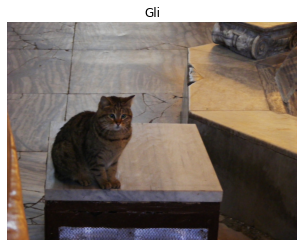

In [13]:
for url,label in zip(table.pic,table.itemLabel):
    image = imread(str(url))
    plt.imshow(image)
    plt.axis('off')
    plt.title(label)
    break

In [16]:
def display_images(table):
    item = [i for i in table.item]
    pic = [i for i in table.pic]
    itemLabel = [i for i in table.itemLabel]

    plt.figure(figsize=(20,20))
    columns = 4
    for i, url in enumerate(pic):
        plt.subplot(len(pic) / columns + 1, columns, i + 1)
        image = imread(url)
        plt.title(itemLabel[i])
        plt.imshow(image) #, plt.xticks([]), plt.yticks([])
        plt.axis('off')

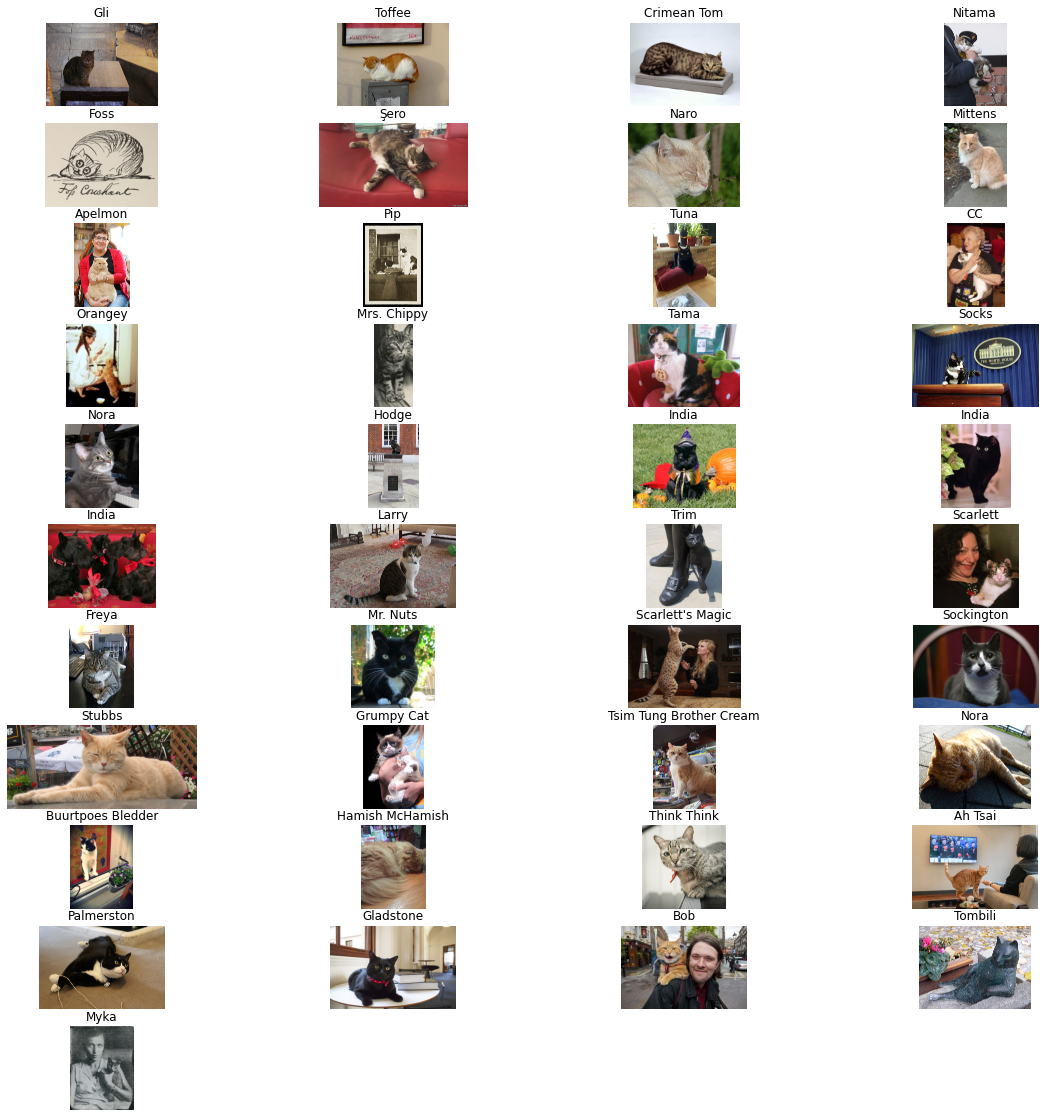

In [19]:
display_images(table)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from IPython.display import set_matplotlib_formats
set_matplotlib_formats("svg")

fig, axs1 = plt.subplots(figsize=(6, 4))
x = np.linspace(0, 2 * np.pi, 400)
y = np.sin(x ** 2)
axs1.plot(x, y)
text = axs1.annotate("vk.com", xy=(0.5,1), xytext=(0.5,0.96), 
                     xycoords='figure fraction',
                     verticalalignment='top',
                     url='vk.com', fontsize=16)
plt.show()

## Map

In [20]:
sparql_query = """
    #added 2017-08
    #defaultView:Map
    SELECT * WHERE {
      ?item wdt:P31/wdt:P279* wd:Q16917;
            wdt:P625 ?point .
    }
    """
#to query another endpoint, change the URL for the service and the query
sparql_service_url = "https://query.wikidata.org/sparql"
result_table = query_wikidata(sparql_query, sparql_service_url)

In [21]:
# extract column
table = simple_table(result_table)
table.head()

,item,point
0,http://www.wikidata.org/entity/Q820012,Point(7.06045 51.5708)
1,http://www.wikidata.org/entity/Q820562,Point(11.1025 47.4875)
2,http://www.wikidata.org/entity/Q828946,Point(8.70942 50.1453)
3,http://www.wikidata.org/entity/Q828948,Point(11.2172 47.6719)
4,http://www.wikidata.org/entity/Q828950,Point(8.38803 49.4863)


In [22]:
import plotly.express as px
import geopandas as gpd

geo_df = gpd.read_file(gpd.datasets.get_path('naturalearth_cities'))

px.set_mapbox_access_token(open(".mapbox_token").read())
fig = px.scatter_mapbox(geo_df,
                        lat=geo_df.geometry.y,
                        lon=geo_df.geometry.x,
                        hover_name="name",
                        zoom=1)
fig.show()

ModuleNotFoundError: No module named 'geopandas'